# Olist Dataset - Ədalət Sadıqov

## Libraries

In [32]:
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass
from sqlalchemy.engine import URL
import seaborn as sns

In [2]:
db_password = getpass("Oracle password: ")

engine = create_engine(
    URL.create(
        drivername="oracle+oracledb",
        username="Brazilian_olist",
        password=db_password,
        host="localhost",
        port=1521,
        query={"service_name": "XEPDB1"},
    )
)

In [3]:
test = pd.read_sql("SELECT COUNT(*) AS row_count FROM olist_customers", engine)
test

,row_count
0,99441


## Qusetions

### q1

In [117]:
q1 = """
with delivered as (
select 
order_id,
customer_id,
ORDER_PURCHASE_TIMESTAMP,
order_status
from OLIST_ORDERS
where order_status = 'delivered')
select * from delivered"""


In [118]:

q1_result = pd.read_sql(q1,engine)
q1_result

,order_id,customer_id,order_purchase_timestamp,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,delivered
...,...,...,...,...
96473,67a98da3237e4b4d8d359f32a49bb209,6164f45c309a294c6835a4c8dd5ab0a4,2018-08-02 12:04:40,delivered
96474,14056d7cad6fbef25503befcd851fc72,b75bc7bae07714f99400b0556dd05ff4,2017-05-06 15:13:22,delivered
96475,8b1c9998d2a9e4a2776b425f90619374,88792a3d73cb6740ee74e05acc69ea9c,2017-03-28 07:13:38,delivered
96476,7dbb5ab142acb99429b243fe157f03a7,f673a32389db114ae93a1918ccb75cb3,2017-05-25 18:48:11,delivered


### q2

In [119]:
q2 = """
WITH delivered AS (
    SELECT 
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
)
SELECT * FROM cohort"""


In [120]:

q2_result = pd.read_sql(q2,engine)
q2_result

,customer_unique_id,cohort_month
0,861eff4711a542e4b93843c6dd7febb0,2017-05-01
1,918dc87cd72cd9f6ed4bd442ed785235,2017-09-01
2,5f102dd37243f152aec3607970aad100,2018-02-01
3,9c0096673baf55453a50073f12d1a37f,2018-07-01
4,424aca6872c5bab80780a8dec03b7516,2017-09-01
...,...,...
93353,0b4f18a0cf7872514b14ebf56c56e68f,2017-01-01
93354,547815ef9a8d4503278645b8d39c2a87,2018-07-01
93355,6367e14c6745a59bbda1939dec7ff914,2018-04-01
93356,9e09e0d9da7daf1871fbbe13d799a94e,2017-11-01


### q3

In [121]:
q3 = """
WITH delivered as (
    SELECT 
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort as (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
),
activity as (
    select
    oc.customer_unique_id,
    trunc(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'),'MM') as order_month
    from OLIST_CUSTOMERS oc
    join delivered d
    on d.customer_id = oc.CUSTOMER_ID)
select ac.customer_unique_id, order_month, cohort_month from activity ac
join cohort coh
on ac.customer_unique_id = coh.customer_unique_id"""

In [122]:
q3_result = pd.read_sql(q3,engine)
q3_result

,customer_unique_id,order_month,cohort_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-01,2017-09-01
1,af07308b275d755c9edb36a90c618231,2018-07-01,2018-07-01
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,2018-08-01
3,7c142cf63193a1473d2e66489a9ae977,2017-11-01,2017-11-01
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,2018-02-01
...,...,...,...
96473,ad6780efb9500f433294fb26028a2477,2018-08-01,2018-08-01
96474,3b295e63da0b0a6e4ca92a7695e71a6b,2017-05-01,2017-05-01
96475,337f09c64e8fcd944c766e1829f601e5,2017-03-01,2017-03-01
96476,39cceffc91e211a0f4c5548c935618d5,2017-05-01,2017-05-01


### q4

In [123]:
q4 = """
WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
),
activity AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'), 'MM') AS order_month
    FROM olist_customers oc
    JOIN delivered d
        ON d.customer_id = oc.customer_id
)
SELECT
    ac.customer_unique_id,
    ac.order_month,
    coh.cohort_month,
    MONTHS_BETWEEN(ac.order_month, coh.cohort_month) AS period_number
FROM activity ac
JOIN cohort coh
    ON ac.customer_unique_id = coh.customer_unique_id
    where MONTHS_BETWEEN(ac.order_month, coh.cohort_month) > 0"""

In [124]:
q4_result = pd.read_sql(q4,engine)
q4_result

,customer_unique_id,order_month,cohort_month,period_number
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-01,2017-09-01,1
1,ccafc1c3f270410521c3c6f3b249870f,2018-06-01,2016-10-01,20
2,6e26bbeaa107ec34112c64e1ee31c0f5,2018-01-01,2017-07-01,6
3,65ee274b862c5c053367be8a70dbc029,2018-05-01,2018-04-01,1
4,995fe9426f030109b1614044edaf46d9,2018-03-01,2017-10-01,5
...,...,...,...,...
1894,e2492e4188991b6276a4a62a287a5451,2018-04-01,2018-02-01,2
1895,53beace9d0aa08b64d759d5f5a66550c,2017-12-01,2017-04-01,8
1896,d66f438b3fcdcf22e7224aaeaf525443,2017-11-01,2017-08-01,3
1897,d0924cc48eeb9e613a31e365ba1db47d,2018-01-01,2017-07-01,6


### q5

In [125]:
q5 = """
WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
),
activity AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'), 'MM') AS order_month
    FROM olist_customers oc
    JOIN delivered d
        ON d.customer_id = oc.customer_id
),
period AS (
    SELECT
        ac.customer_unique_id,
        coh.cohort_month,
        MONTHS_BETWEEN(ac.order_month, coh.cohort_month) AS period_number
    FROM activity ac
    JOIN cohort coh
        ON ac.customer_unique_id = coh.customer_unique_id
)
SELECT
    cohort_month,
    COUNT(DISTINCT CASE WHEN period_number = 0 THEN customer_unique_id END) AS period_0,
    COUNT(DISTINCT CASE WHEN period_number = 1 THEN customer_unique_id END) AS period_1,
    COUNT(DISTINCT CASE WHEN period_number = 2 THEN customer_unique_id END) AS period_2,
    COUNT(DISTINCT CASE WHEN period_number = 3 THEN customer_unique_id END) AS period_3,
    COUNT(DISTINCT CASE WHEN period_number = 4 THEN customer_unique_id END) AS period_4,
    COUNT(DISTINCT CASE WHEN period_number = 5 THEN customer_unique_id END) AS period_5,
    COUNT(DISTINCT CASE WHEN period_number = 6 THEN customer_unique_id END) AS period_6
FROM period
GROUP BY cohort_month
ORDER BY cohort_month"""

In [126]:
q5_result = pd.read_sql(q5,engine)
q5_result

,cohort_month,period_0,period_1,period_2,period_3,period_4,period_5,period_6
0,2016-09-01,1,0,0,0,0,0,0
1,2016-10-01,262,0,0,0,0,0,1
2,2016-12-01,1,1,0,0,0,0,0
3,2017-01-01,717,2,2,1,3,1,3
4,2017-02-01,1628,3,5,2,7,2,4
5,2017-03-01,2503,11,9,10,9,4,4
6,2017-04-01,2256,14,5,4,6,6,8
7,2017-05-01,3451,16,16,10,10,11,14
8,2017-06-01,3037,15,12,13,9,12,11
9,2017-07-01,3752,20,13,9,11,8,12


### q6

In [127]:
q6 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
)
select 
    cohort_month,
    count(distinct customer_unique_id) as cohort_size
from cohort
group by cohort_month
order by cohort_month"""

In [128]:
q6_result = pd.read_sql(q6,engine)
q6_result

,cohort_month,cohort_size
0,2016-09-01,1
1,2016-10-01,262
2,2016-12-01,1
3,2017-01-01,717
4,2017-02-01,1628
5,2017-03-01,2503
6,2017-04-01,2256
7,2017-05-01,3451
8,2017-06-01,3037
9,2017-07-01,3752


### q7

In [129]:
q7 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
),
activity AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'), 'MM') AS order_month
    FROM olist_customers oc
    JOIN delivered d
        ON d.customer_id = oc.customer_id
),
period AS (
    SELECT
        ac.customer_unique_id,
        coh.cohort_month,
        MONTHS_BETWEEN(ac.order_month, coh.cohort_month) AS period_number
    FROM activity ac
    JOIN cohort coh
        ON ac.customer_unique_id = coh.customer_unique_id
),
matrix AS (
    SELECT
        cohort_month,
        COUNT(DISTINCT CASE WHEN period_number = 0 THEN customer_unique_id END) AS period_0,
        COUNT(DISTINCT CASE WHEN period_number = 1 THEN customer_unique_id END) AS period_1,
        COUNT(DISTINCT CASE WHEN period_number = 2 THEN customer_unique_id END) AS period_2,
        COUNT(DISTINCT CASE WHEN period_number = 3 THEN customer_unique_id END) AS period_3,
        COUNT(DISTINCT CASE WHEN period_number = 4 THEN customer_unique_id END) AS period_4,
        COUNT(DISTINCT CASE WHEN period_number = 5 THEN customer_unique_id END) AS period_5,
        COUNT(DISTINCT CASE WHEN period_number = 6 THEN customer_unique_id END) AS period_6
    FROM period
    GROUP BY cohort_month
)
SELECT
    cohort_month,
    period_0,
    ROUND(period_0 / NULLIF(period_0, 0) * 100, 1) AS pct_0,
    ROUND(period_1 / NULLIF(period_0, 0) * 100, 1) AS pct_1,
    ROUND(period_2 / NULLIF(period_0, 0) * 100, 1) AS pct_2,
    ROUND(period_3 / NULLIF(period_0, 0) * 100, 1) AS pct_3,
    ROUND(period_4 / NULLIF(period_0, 0) * 100, 1) AS pct_4,
    ROUND(period_5 / NULLIF(period_0, 0) * 100, 1) AS pct_5,
    ROUND(period_6 / NULLIF(period_0, 0) * 100, 1) AS pct_6
FROM matrix
WHERE period_0 <> 1
ORDER BY cohort_month
"""

In [130]:
q7_result = pd.read_sql(q7,engine)
q7_result

,cohort_month,period_0,pct_0,pct_1,pct_2,pct_3,pct_4,pct_5,pct_6
0,2016-10-01,262,100,0.0,0.0,0.0,0.0,0.0,0.4
1,2017-01-01,717,100,0.3,0.3,0.1,0.4,0.1,0.4
2,2017-02-01,1628,100,0.2,0.3,0.1,0.4,0.1,0.2
3,2017-03-01,2503,100,0.4,0.4,0.4,0.4,0.2,0.2
4,2017-04-01,2256,100,0.6,0.2,0.2,0.3,0.3,0.4
5,2017-05-01,3451,100,0.5,0.5,0.3,0.3,0.3,0.4
6,2017-06-01,3037,100,0.5,0.4,0.4,0.3,0.4,0.4
7,2017-07-01,3752,100,0.5,0.3,0.2,0.3,0.2,0.3
8,2017-08-01,4057,100,0.7,0.3,0.3,0.3,0.5,0.3
9,2017-09-01,4004,100,0.7,0.5,0.3,0.4,0.2,0.2


### q8

In [131]:
q8 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
),
activity AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'), 'MM') AS order_month
    FROM olist_customers oc
    JOIN delivered d
        ON d.customer_id = oc.customer_id
),
period AS (
    SELECT
        ac.customer_unique_id,
        coh.cohort_month,
        MONTHS_BETWEEN(ac.order_month, coh.cohort_month) AS period_number
    FROM activity ac
    JOIN cohort coh
        ON ac.customer_unique_id = coh.customer_unique_id
),
cohort_size AS (
    SELECT cohort_month, COUNT(DISTINCT customer_unique_id) AS size_0
    FROM cohort
    GROUP BY cohort_month
),
max_date AS (
    SELECT MAX(order_month) AS max_order_month FROM activity
),
periods AS (
    SELECT LEVEL - 1 AS period_number
    FROM dual
    CONNECT BY LEVEL <= 7         
),
grid AS (
    SELECT cs.cohort_month, p.period_number, cs.size_0
    FROM cohort_size cs
    CROSS JOIN periods p
    CROSS JOIN max_date md
    WHERE ADD_MONTHS(cs.cohort_month, p.period_number) <= md.max_order_month
),
actuals AS (
    SELECT cohort_month, period_number, COUNT(DISTINCT customer_unique_id) AS active_customers
    FROM period
    GROUP BY cohort_month, period_number
)
SELECT
    g.period_number,
    COUNT(*) AS cohorts_observed,
    ROUND(AVG(NVL(a.active_customers, 0) / g.size_0 * 100), 1) AS avg_retention_pct
FROM grid g
LEFT JOIN actuals a
    ON a.cohort_month = g.cohort_month AND a.period_number = g.period_number
GROUP BY g.period_number
ORDER BY g.period_number"""

In [132]:
q8_result = pd.read_sql(q8,engine)
q8_result

,period_number,cohorts_observed,avg_retention_pct
0,0,23,100.0
1,1,22,5.0
2,2,21,0.3
3,3,20,0.2
4,4,19,0.2
5,5,18,0.2
6,6,17,0.2


### q9

In [133]:
q9 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
),
activity AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'), 'MM') AS order_month
    FROM olist_customers oc
    JOIN delivered d
        ON d.customer_id = oc.customer_id
),
period AS (
    SELECT
        ac.customer_unique_id,
        coh.cohort_month,
        MONTHS_BETWEEN(ac.order_month, coh.cohort_month) AS period_number
    FROM activity ac
    JOIN cohort coh
        ON ac.customer_unique_id = coh.customer_unique_id
),
cohort_size AS (
    SELECT cohort_month, COUNT(DISTINCT customer_unique_id) AS size_0
    FROM cohort
    GROUP BY cohort_month
),
month1_actual AS (
    SELECT cohort_month, COUNT(DISTINCT customer_unique_id) AS size_1
    FROM period
    WHERE period_number = 1
    GROUP BY cohort_month
),
max_date AS (
    SELECT MAX(order_month) AS max_order_month FROM activity
),
month1_rate AS (
    SELECT
        cs.cohort_month,
        cs.size_0,
        NVL(m1.size_1, 0) AS size_1,
        ROUND(NVL(m1.size_1, 0) / cs.size_0 * 100, 1) AS pct_month1
    FROM cohort_size cs
    LEFT JOIN month1_actual m1
        ON m1.cohort_month = cs.cohort_month
    CROSS JOIN max_date md
    WHERE ADD_MONTHS(cs.cohort_month, 1) <= md.max_order_month
)
SELECT * FROM (
    SELECT cohort_month, size_0, pct_month1, 'BEST' AS label
    FROM month1_rate
    ORDER BY pct_month1 DESC
    FETCH FIRST 1 ROW ONLY
)
UNION ALL
SELECT * FROM (
    SELECT cohort_month, size_0, pct_month1, 'WORST' AS label
    FROM month1_rate
    ORDER BY pct_month1 ASC
    FETCH FIRST 1 ROW ONLY
)""" 

In [134]:
q9_result = pd.read_sql(q9,engine)
q9_result

,cohort_month,size_0,pct_month1,label
0,2016-12-01,1,100,BEST
1,2016-09-01,1,0,WORST


### q10

In [135]:
q10 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
),
order_revenue AS (
    SELECT
        order_id,
        SUM(price) AS revenue          
    FROM olist_order_items
    GROUP BY order_id
),
activity AS (
    SELECT
        d.order_id,
        oc.customer_unique_id,
        TRUNC(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'), 'MM') AS order_month
    FROM olist_customers oc
    JOIN delivered d
        ON d.customer_id = oc.customer_id
),
period AS (
    SELECT
        ac.order_id,
        ac.customer_unique_id,
        coh.cohort_month,
        MONTHS_BETWEEN(ac.order_month, coh.cohort_month) AS period_number
    FROM activity ac
    JOIN cohort coh
        ON ac.customer_unique_id = coh.customer_unique_id
)
SELECT
    p.cohort_month,
    SUM(CASE WHEN p.period_number = 0 THEN r.revenue ELSE 0 END) AS revenue_0,
    SUM(CASE WHEN p.period_number = 1 THEN r.revenue ELSE 0 END) AS revenue_1,
    SUM(CASE WHEN p.period_number = 2 THEN r.revenue ELSE 0 END) AS revenue_2,
    SUM(CASE WHEN p.period_number = 3 THEN r.revenue ELSE 0 END) AS revenue_3,
    SUM(CASE WHEN p.period_number = 4 THEN r.revenue ELSE 0 END) AS revenue_4,
    SUM(CASE WHEN p.period_number = 5 THEN r.revenue ELSE 0 END) AS revenue_5,
    SUM(CASE WHEN p.period_number = 6 THEN r.revenue ELSE 0 END) AS revenue_6
FROM period p
JOIN order_revenue r
    ON r.order_id = p.order_id
GROUP BY p.cohort_month
ORDER BY p.cohort_month"""

In [136]:
q10_result = pd.read_sql(q10,engine)
q10_result

,cohort_month,revenue_0,revenue_1,revenue_2,revenue_3,revenue_4,revenue_5,revenue_6
0,2016-09-01,134.97,0.00,0.00,0.00,0.00,0.00,0.00
1,2016-10-01,40325.11,0.00,0.00,0.00,0.00,0.00,99.99
2,2016-12-01,10.90,10.90,0.00,0.00,0.00,0.00,0.00
3,2017-01-01,111787.46,76.12,82.89,75.00,199.70,59.99,372.95
4,2017-02-01,234147.28,434.90,484.50,89.25,978.22,49.99,583.89
5,2017-03-01,358681.06,1372.26,1452.24,1645.05,989.33,1306.99,593.68
6,2017-04-01,338637.93,2638.53,800.38,670.78,1040.29,1046.38,1832.67
7,2017-05-01,484958.53,1504.60,2374.78,1321.57,1048.69,1331.95,2668.07
8,2017-06-01,416935.13,1765.30,1742.94,1278.55,1243.77,1395.68,1245.67
9,2017-07-01,475042.39,2602.45,1068.75,1005.16,912.24,1653.48,2235.46


### q11

In [137]:
q11 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
customer_first_order AS (
    SELECT
        oc.customer_unique_id,
        oc.customer_state,
        TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS') AS order_date,
        ROW_NUMBER() OVER (
            PARTITION BY oc.customer_unique_id
            ORDER BY TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')
        ) AS rn
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
),
cohort AS (
    SELECT
        customer_unique_id,
        customer_state,
        TRUNC(order_date, 'MM') AS cohort_month
    FROM customer_first_order
    WHERE rn = 1
),
activity AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'), 'MM') AS order_month
    FROM olist_customers oc
    JOIN delivered d
        ON d.customer_id = oc.customer_id
),
period AS (
    SELECT
        ac.customer_unique_id,
        coh.customer_state,
        coh.cohort_month,
        MONTHS_BETWEEN(ac.order_month, coh.cohort_month) AS period_number
    FROM activity ac
    JOIN cohort coh
        ON ac.customer_unique_id = coh.customer_unique_id
),
max_date AS (
    SELECT MAX(order_month) AS max_order_month FROM activity
),
censored_cohort AS (
    SELECT c.*
    FROM cohort c
    CROSS JOIN max_date md
    WHERE ADD_MONTHS(c.cohort_month, 1) <= md.max_order_month
),
state_size AS (
    SELECT customer_state, COUNT(DISTINCT customer_unique_id) AS cohort_size
    FROM censored_cohort
    GROUP BY customer_state
),
state_month1 AS (
    SELECT p.customer_state, COUNT(DISTINCT p.customer_unique_id) AS size_1
    FROM period p
    JOIN censored_cohort cc
        ON cc.customer_unique_id = p.customer_unique_id
    WHERE p.period_number = 1
    GROUP BY p.customer_state
),
state_rate AS (
    SELECT
        ss.customer_state,
        ss.cohort_size,
        NVL(sm.size_1, 0) AS size_1,
        ROUND(NVL(sm.size_1, 0) / ss.cohort_size * 100, 1) AS pct_month1
    FROM state_size ss
    LEFT JOIN state_month1 sm
        ON sm.customer_state = ss.customer_state
    WHERE ss.cohort_size >= 50
)
SELECT * FROM (
    SELECT customer_state, cohort_size, pct_month1, 'TOP' AS rank_group
    FROM state_rate
    ORDER BY pct_month1 DESC
    FETCH FIRST 5 ROWS ONLY
)
UNION ALL
SELECT * FROM (
    SELECT customer_state, cohort_size, pct_month1, 'BOTTOM' AS rank_group
    FROM state_rate
    ORDER BY pct_month1 ASC
    FETCH FIRST 5 ROWS ONLY
)
ORDER BY 4, 3 DESC"""

In [138]:
q11_result = pd.read_sql(q11,engine)
q11_result

,customer_state,cohort_size,pct_month1,rank_group
0,MA,669,0.1,BOTTOM
1,AM,136,0.0,BOTTOM
2,RN,444,0.0,BOTTOM
3,TO,254,0.0,BOTTOM
4,AC,73,0.0,BOTTOM
5,AP,64,1.6,TOP
6,MT,816,1.1,TOP
7,PI,445,0.9,TOP
8,RJ,11219,0.6,TOP
9,BA,3001,0.6,TOP


### q12

In [139]:
q12 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
customer_orders AS (
    SELECT
        oc.customer_unique_id,
        TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS') AS order_date,
        ROW_NUMBER() OVER (
            PARTITION BY oc.customer_unique_id
            ORDER BY TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')
        ) AS rn
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
),
first_order AS (
    SELECT customer_unique_id, order_date AS first_date
    FROM customer_orders
    WHERE rn = 1
),
second_order AS (
    SELECT customer_unique_id, order_date AS second_date
    FROM customer_orders
    WHERE rn = 2
),
gap AS (
    SELECT
        f.customer_unique_id,
        f.first_date,
        s.second_date,
        TRUNC(s.second_date) - TRUNC(f.first_date) AS day_gap
    FROM first_order f
    JOIN second_order s
        ON s.customer_unique_id = f.customer_unique_id
),
bucketed AS (
    SELECT
        customer_unique_id,
        day_gap,
        CASE
            WHEN day_gap BETWEEN 0 AND 30 THEN '0-30'
            WHEN day_gap BETWEEN 31 AND 60 THEN '31-60'
            WHEN day_gap BETWEEN 61 AND 90 THEN '61-90'
            ELSE '90+'
        END AS gap_bucket
    FROM gap
)
SELECT
    gap_bucket,
    COUNT(*) AS customer_count
FROM bucketed
GROUP BY gap_bucket
ORDER BY
    CASE gap_bucket
        WHEN '0-30'  THEN 1
        WHEN '31-60' THEN 2
        WHEN '61-90' THEN 3
        WHEN '90+'   THEN 4
    END"""

In [140]:
q12_result = pd.read_sql(q12,engine)
q12_result

,gap_bucket,customer_count
0,0-30,1416
1,31-60,296
2,61-90,196
3,90+,893


### q13

In [141]:
q13 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
cohort AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(MIN(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')), 'MM') AS cohort_month
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
    GROUP BY oc.customer_unique_id
),
activity AS (
    SELECT
        oc.customer_unique_id,
        TRUNC(TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS'), 'MM') AS order_month
    FROM olist_customers oc
    JOIN delivered d
        ON d.customer_id = oc.customer_id
),
period AS (
    SELECT
        ac.customer_unique_id,
        ac.order_month,
        coh.cohort_month,
        MONTHS_BETWEEN(ac.order_month, coh.cohort_month) AS period_number
    FROM activity ac
    JOIN cohort coh
        ON ac.customer_unique_id = coh.customer_unique_id
),
monthly AS (
    SELECT
        order_month,
        COUNT(DISTINCT CASE WHEN period_number = 0 THEN customer_unique_id END) AS new_customers,
        COUNT(DISTINCT CASE WHEN period_number > 0 THEN customer_unique_id END) AS repeat_customers,
        COUNT(DISTINCT customer_unique_id) AS total_customers
    FROM period
    GROUP BY order_month
)
SELECT
    order_month,
    new_customers,
    repeat_customers,
    total_customers,
    ROUND(new_customers / total_customers * 100, 1) AS pct_new,
    ROUND(repeat_customers / total_customers * 100, 1) AS pct_repeat
FROM monthly
ORDER BY order_month"""

In [142]:
q13_result = pd.read_sql(q13,engine)
q13_result

,order_month,new_customers,repeat_customers,total_customers,pct_new,pct_repeat
0,2016-09-01,1,0,1,100.0,0.0
1,2016-10-01,262,0,262,100.0,0.0
2,2016-12-01,1,0,1,100.0,0.0
3,2017-01-01,717,1,718,99.9,0.1
4,2017-02-01,1628,2,1630,99.9,0.1
5,2017-03-01,2503,5,2508,99.8,0.2
6,2017-04-01,2256,18,2274,99.2,0.8
7,2017-05-01,3451,28,3479,99.2,0.8
8,2017-06-01,3037,39,3076,98.7,1.3
9,2017-07-01,3752,50,3802,98.7,1.3


### q14

In [143]:
q14 = """WITH delivered AS (
    SELECT
        order_id,
        customer_id,
        order_purchase_timestamp,
        order_status
    FROM olist_orders
    WHERE order_status = 'delivered'
),
customer_orders AS (
    SELECT
        oc.customer_unique_id,
        TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS') AS order_date,
        ROW_NUMBER() OVER (
            PARTITION BY oc.customer_unique_id
            ORDER BY TO_DATE(d.order_purchase_timestamp, 'YYYY-MM-DD HH24:MI:SS')
        ) AS rn
    FROM delivered d
    JOIN olist_customers oc
        ON d.customer_id = oc.customer_id
),
cohort AS (
    SELECT
        customer_unique_id,
        TRUNC(order_date, 'MM') AS cohort_month
    FROM customer_orders
    WHERE rn = 1
),
ever_returned AS (
    SELECT
        customer_unique_id,
        MAX(rn) AS total_orders
    FROM customer_orders
    GROUP BY customer_unique_id
),
max_date AS (
    SELECT TRUNC(MAX(order_date), 'MM') AS max_order_month FROM customer_orders
),
cohort_survival AS (
    SELECT
        c.cohort_month,
        er.customer_unique_id,
        CASE WHEN er.total_orders >= 2 THEN 1 ELSE 0 END AS returned_flag
    FROM cohort c
    JOIN ever_returned er
        ON er.customer_unique_id = c.customer_unique_id
)
SELECT
    cs.cohort_month,
    COUNT(*) AS cohort_size,
    SUM(cs.returned_flag) AS returned_customers,
    ROUND(SUM(cs.returned_flag) / COUNT(*) * 100, 1) AS pct_ever_returned,
    ROUND(MONTHS_BETWEEN(md.max_order_month, cs.cohort_month), 0) AS months_observed
FROM cohort_survival cs
CROSS JOIN max_date md
GROUP BY cs.cohort_month, md.max_order_month
ORDER BY cs.cohort_month"""


In [144]:
q14_result = pd.read_sql(q14,engine)
q14_result

,cohort_month,cohort_size,returned_customers,pct_ever_returned,months_observed
0,2016-09-01,1,0,0.0,23
1,2016-10-01,262,12,4.6,22
2,2016-12-01,1,1,100.0,20
3,2017-01-01,717,52,7.3,19
4,2017-02-01,1628,66,4.1,18
5,2017-03-01,2503,121,4.8,17
6,2017-04-01,2256,102,4.5,16
7,2017-05-01,3451,182,5.3,15
8,2017-06-01,3037,161,5.3,14
9,2017-07-01,3752,175,4.7,13


## Vizualation

### Heatmap

In [145]:

q7_result['cohort_month'] = pd.to_datetime(q7_result['cohort_month'])
q7_result = q7_result.set_index('cohort_month')[['pct_1','pct_2','pct_3','pct_4','pct_5','pct_6']]

In [146]:

q7_result


,pct_1,pct_2,pct_3,pct_4,pct_5,pct_6
cohort_month,,,,,,
2016-10-01,0.0,0.0,0.0,0.0,0.0,0.4
2017-01-01,0.3,0.3,0.1,0.4,0.1,0.4
2017-02-01,0.2,0.3,0.1,0.4,0.1,0.2
2017-03-01,0.4,0.4,0.4,0.4,0.2,0.2
2017-04-01,0.6,0.2,0.2,0.3,0.3,0.4
2017-05-01,0.5,0.5,0.3,0.3,0.3,0.4
2017-06-01,0.5,0.4,0.4,0.3,0.4,0.4
2017-07-01,0.5,0.3,0.2,0.3,0.2,0.3
2017-08-01,0.7,0.3,0.3,0.3,0.5,0.3


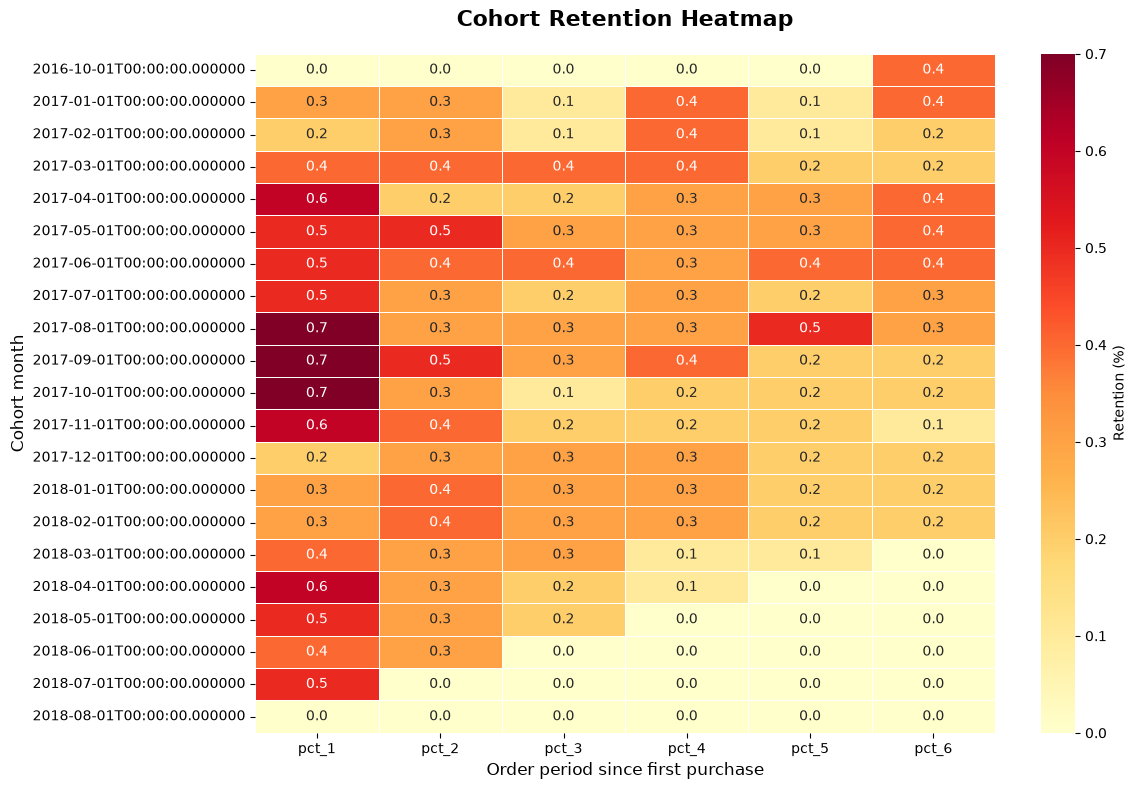

In [148]:
plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    q7_result,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    cbar_kws={"label": "Retention (%)"}
)

ax.set_title("Cohort Retention Heatmap", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Order period since first purchase", fontsize=12)
ax.set_ylabel("Cohort month", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Average Cohort Retention Curve

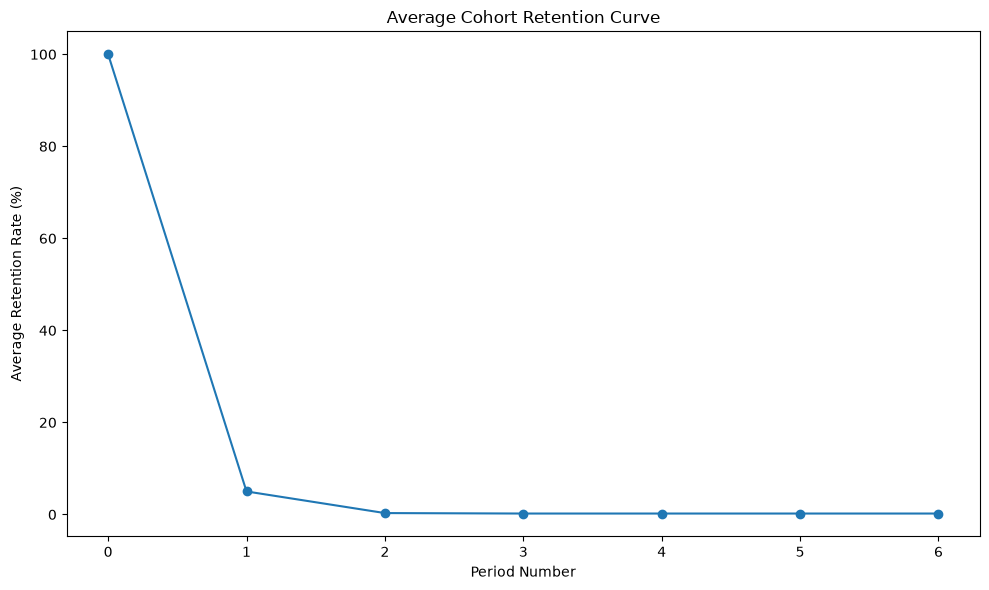

In [149]:
plt.figure(figsize=(10, 6))
plt.plot(q8_result['period_number'], q8_result['avg_retention_pct'], marker='o')
plt.title('Average Cohort Retention Curve')
plt.xlabel('Period Number')
plt.ylabel('Average Retention Rate (%)')
plt.tight_layout()
plt.show()

### Cohort size

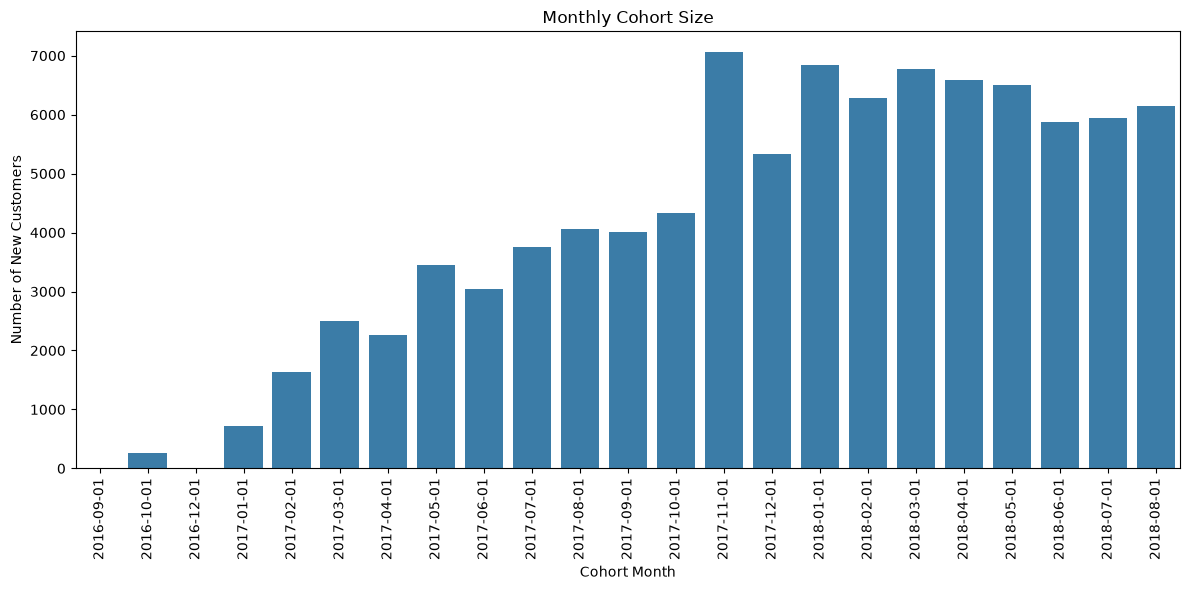

In [151]:
plt.figure(figsize=(12, 6))
sns.barplot(data=q6_result, x='cohort_month', y='cohort_size', color='#2980b9')
plt.title('Monthly Cohort Size')
plt.xlabel('Cohort Month')
plt.ylabel('Number of New Customers')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### New vs repeat customers

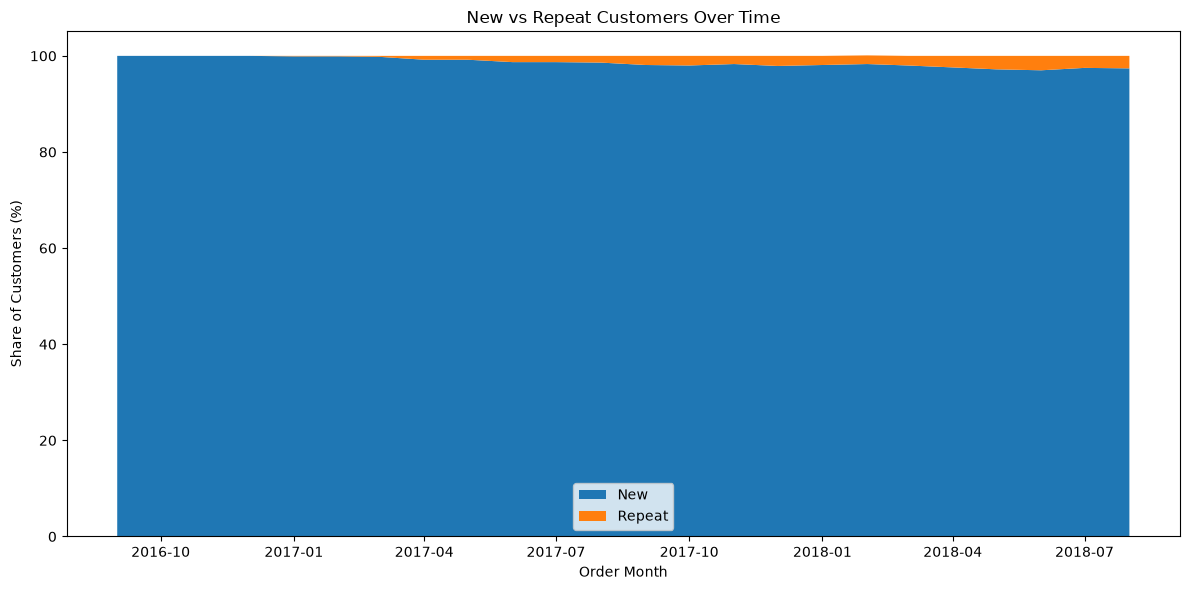

In [154]:
plt.figure(figsize=(12, 6))
plt.stackplot(
    q13_result['order_month'],
    q13_result['pct_new'],
    q13_result['pct_repeat'],
    labels=['New', 'Repeat'],
)
plt.title('New vs Repeat Customers Over Time')
plt.xlabel('Order Month')
plt.ylabel('Share of Customers (%)')
plt.legend()
plt.tight_layout()
plt.show()

### Top vs Bottom States

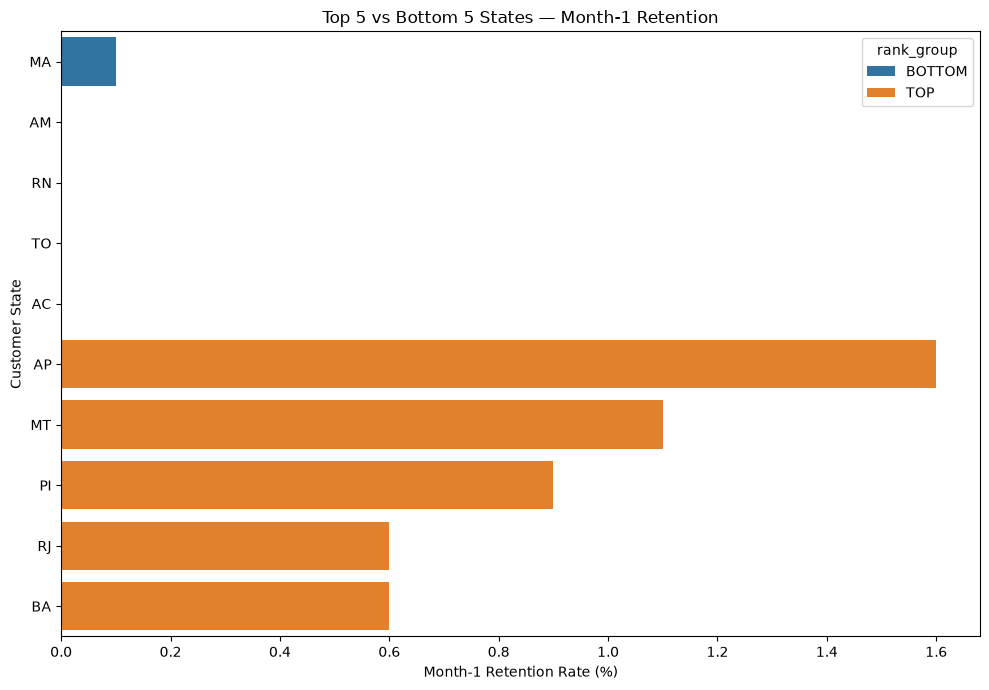

In [155]:
plt.figure(figsize=(10, 7))
sns.barplot(data=q11_result, x='pct_month1', y='customer_state', hue='rank_group')
plt.title('Top 5 vs Bottom 5 States — Month-1 Retention')
plt.xlabel('Month-1 Retention Rate (%)')
plt.ylabel('Customer State')
plt.tight_layout()
plt.show()

## insights

### Insight 1 — Sharp retention drop from Period 0 to Period 1


`q8_result` shows that average retention drops from **100%** in Period 0 to just **5.0%** in Period 1. This means a **95 percentage-point** decline within a single period. The change is accompanied by a decrease in `cohorts_observed` from 23 to 22. Therefore, the result cannot be explained only by a censoring effect — most customers simply do not return after their first month.

**What it means:** Repeat purchasing is very weak on Olist. Customers appear to use the platform mainly to satisfy a specific need, and only a small share return to make another purchase. This is different from subscription-based businesses, where regular customer return is an essential part of the business model.



### Insight 2 — The BEST/WORST cohort results in Q9 can be misleading


In `q9_result`, the BEST cohort is **2016-12** (pct_month1 = **100%**), while the WORST cohort is **2016-09** (pct_month1 = **0%**). However, both cohorts have a `size_0` of only **1**. In other words, the 100% result comes from one customer returning, while the 0% result comes from one customer not returning.

Because of this, these results should not be treated as meaningful measures of cohort performance. Applying the **`cohort_size >= 50`** filter used in Q11 would make the comparison more reliable. With this filter, larger cohorts such as 2017-08 (**n=4057**) and 2018-08 (**n=6144**) can be considered instead.

**What it means:** Percentages from very small cohorts can easily become 0% or 100%. Therefore, cohort analysis should consider not only the percentage itself but also the number of customers behind that percentage.



### Insight 3 — Two distinct return patterns among repeat customers


According to `q12_result`, there are **2801** repeat customers in total. Of these, **1416 (50.6%)** made another purchase within 30 days of their first order. **296 customers (10.6%)** returned within 31–60 days, while **196 (7.0%)** returned within 61–90 days. Meanwhile, **893 customers (31.9%)** placed their second order more than 90 days later.

The interesting point is that the 31–90 day period is relatively less active. A large share of repeat customers return fairly quickly, while another sizeable group comes back much later.

**What it means:** This may indicate two different customer behavior patterns: customers who return quickly and customers who return after a long gap. However, these figures do not explain why customers return. To understand the reason behind the behavior, these groups should be compared with product categories and other customer characteristics.



### Insight 4 — Repeat customer share increases, but stays below 3%



According to `q13_result`, `pct_repeat` starts at **0.1% in 2017-01** and reaches its highest point of **3.0% in 2018-05**. It then falls to **2.5–2.6%** in 2018-07 and 2018-08.

So, although the repeat customer share increases over time, the overall level remains very low. Even after **18 months of observation**, more than **97% of customers in a given month are still new customers**.

**What it means:** This increase should not automatically be interpreted as an improvement in customer loyalty. As time passes, more cohorts simply have the opportunity to make another purchase, which naturally increases the repeat customer share. The key point is not the upward movement itself, but the fact that the overall level remains **below 3%**.


### Insight 5 — Customer growth peaks in late 2017, then stabilizes


`q6_result` shows rapid cohort growth from **262 customers in 2016-10** to **7060 in 2017-11**, the largest cohort. After that, monthly cohort sizes remain relatively stable at **5878–6842** throughout 2018.

**What it means:** The marketplace appears to have moved from a rapid customer-acquisition phase into a more stable stage. With new customer growth flattening, increasing **repeat purchases** becomes more important for further growth.


### Insight 6 — Most churn happens between Period 0 and Period 1


In `q7_result`, retention remains very low after Period 1, generally within **0.0%–0.7%**. For example, the 2017-08 cohort has retention of **0.7%, 0.3%, 0.3%, 0.3%, 0.5%, and 0.3%** from Period 1 to Period 6.

**What it means:** Most customer loss happens during the first month. Once customers fail to return in Period 1, very few come back later. Therefore, retention efforts should focus on the **first 30 days**, rather than waiting until later months.



### Insight 7 — Retention is similar across large states, while small-state extremes are unreliable


`q11_result` shows that the two largest states, RJ (**n=11219, 0.6%**) and BA (**n=3001, 0.6%**), have almost identical retention. In contrast, AP reports **1.6%** with only **n=64**, while AM (**n=136**), AC (**n=73**), and TO (**n=254**) report **0.0%**.

**What it means:** The similar results among larger states provide a more reliable picture of retention, while the extreme values from small samples may be driven by only a few customers. Regional differences should therefore be interpreted cautiously.


### Insight 8 — Even with 19+ months of observation, lifetime repeat purchase stays below ~7%


In `q14_result`, the 2017-01 cohort, with **19 months of observation**, has a `pct_ever_returned` of **7.3%**, one of the highest meaningful values in the table. The 2017-02 and 2017-03 cohorts are lower at **4.1%** and **4.8%**.

**What it means:** Even with enough time to observe customers for more than a year, only a small share ever make a second purchase. This supports Insights 1 and 6: low repeat purchasing appears to be a **structural issue**, not simply a matter of customers needing more time to return.


# Final conclusion

## Key Finding: Weak Repeat Purchasing



Across Q1–Q15 and the 8 insights, the results consistently show **very weak repeat purchasing** on the Olist marketplace.

* **Period retention (Q7/Q8):** Retention falls from **100% to 5.0%** between Period 0 and Period 1, with `cohorts_observed` changing only from 23 to 22.
* **Retention floor (Q7):** After Period 1, retention remains around **0.0%–0.7%**, showing that most churn happens within the first 30 days.
* **Lifetime return (Q14):** Even with **19 months** of observation, the highest meaningful `pct_ever_returned` is only **7.3%**.
* **New vs. repeat customers (Q13):** `pct_repeat` rises from **0.1% to 3.0%**, but remains below **3%** overall.

Together, these metrics suggest that Olist behaves primarily as a **one-time-purchase marketplace**, where customers often return only when they have a new need rather than developing strong repeat-purchase behavior.


## Business Implication


Customer acquisition grew rapidly during 2016–2017, but cohort sizes stabilized at around **5878–6842** throughout 2018. With new-customer growth flattening, increasing **repeat purchases** becomes an important growth opportunity.



## Key Limitations


* Avoid interpreting results from very small samples (e.g., **n=1 cohorts** or AP with **n=64**) as meaningful.
* **Correlation does not imply causation:** the reasons behind repeat purchases require additional analysis, such as product category and delivery experience.
* Using `customer_unique_id` is essential; using `customer_id` would incorrectly treat the same customer as multiple customers and distort retention.


## Recommendation


The main retention opportunity is the **first 30 days**, when most churn occurs. Targeted re-engagement campaigns, such as second-order incentives or personalized offers, should therefore focus on this period rather than waiting until 60–90 days.
